# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons selectionnés : -appid -name - release_date -required_age -price - dlc_count -metacritic_score -achievements -recommendations -categories -positive -negative -median_playtime_forever -peak_ccu -pct_pos_total

### Notre objectives


## Importation des librairies et du dataset

In [1]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")


## Prétraitement des données


In [2]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Supprimer les jeux sans recommandations
df = df[df['recommendations'] > 0]

## Supprimer 'positif' et 'negative' car redondant avec 'pct_pos_total'
df = df.drop(columns=['positive', 'negative'])

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])

# Verifier les modifications
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])
df.head(10)

Number of samples: 16737
Number of features: 14


,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
0,Counter-Strike 2,2012,0,0.00,1,0,1,4401572,5174,1212356,86,8632939,0,1
1,PUBG: BATTLEGROUNDS,2017,0,0.00,0,0,37,1732007,0,616738,59,2513842,0,1
2,Dota 2,2013,0,0.00,2,90,0,14337,898,555977,81,2452595,0,1
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,7101,117698,87,1803832,1,1
4,Tom Clancy's Rainbow Six® Siege,2015,17,3.99,9,0,0,1165929,2434,89916,84,1168020,1,1
5,Team Fortress 2,2007,0,0.00,1,92,520,41587,0,50817,89,1146642,0,1
6,Terraria,2011,0,9.99,2,83,115,1098792,0,30516,97,1102434,1,1
7,Rust,2018,0,39.99,4,69,92,992825,3675,200902,87,993856,0,1
8,Garry's Mod,2006,0,5.99,0,0,29,984713,1173,32384,96,985010,1,1
9,Apex Legends™,2020,0,0.00,0,88,12,1548,667,151844,67,983230,0,1


## Exploration des données

Features: ['release_year', 'required_age', 'price', 'dlc_count', 'metacritic_score', 'achievements', 'recommendations', 'median_playtime_forever', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'single_player', 'multi_player']


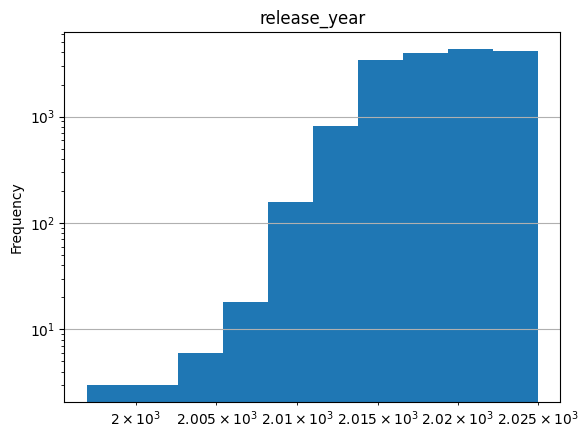

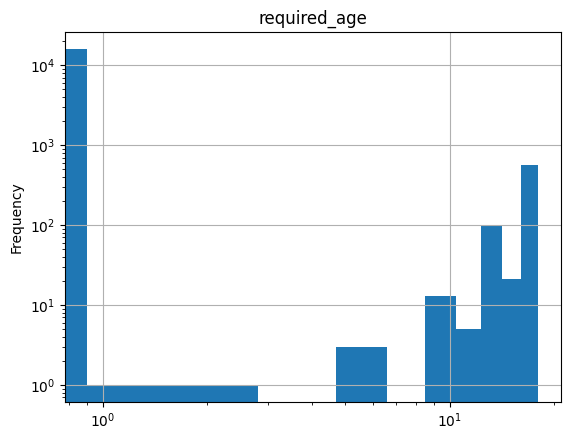

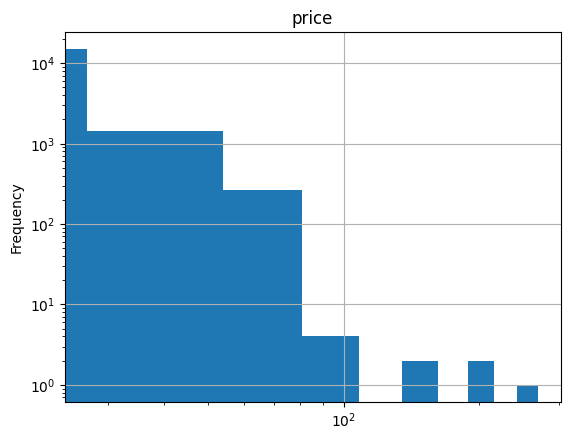

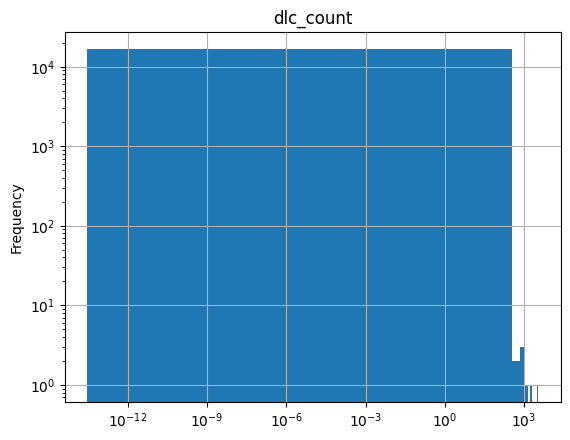

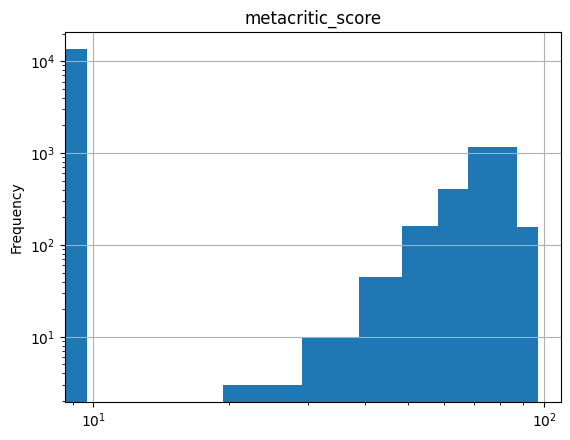

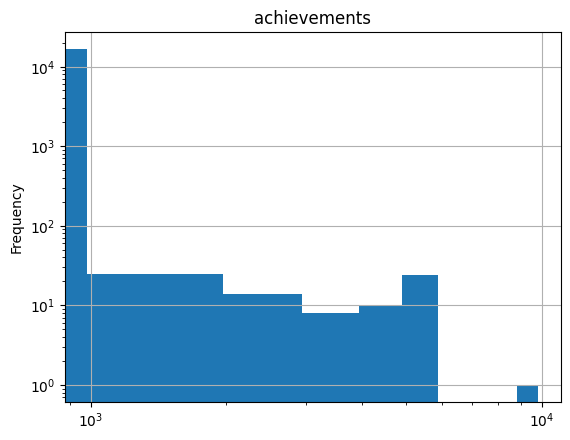

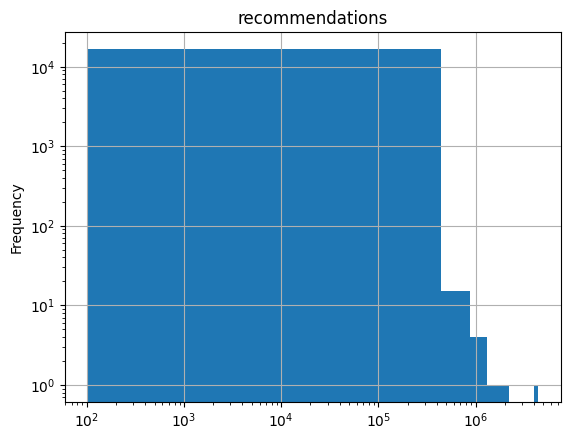

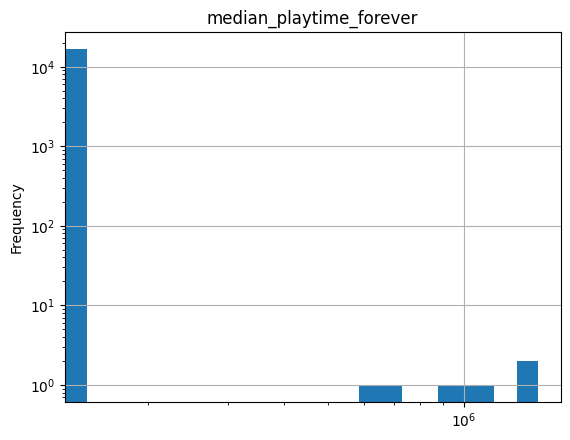

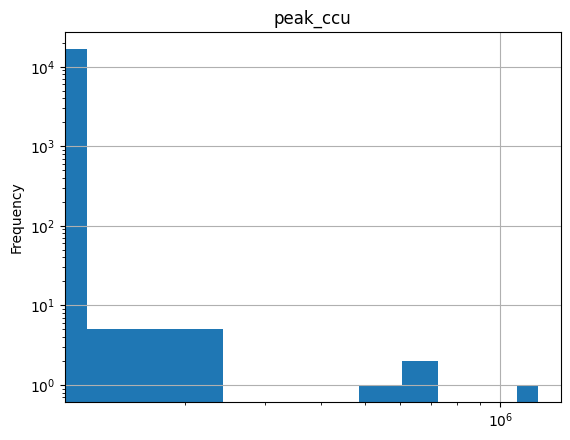

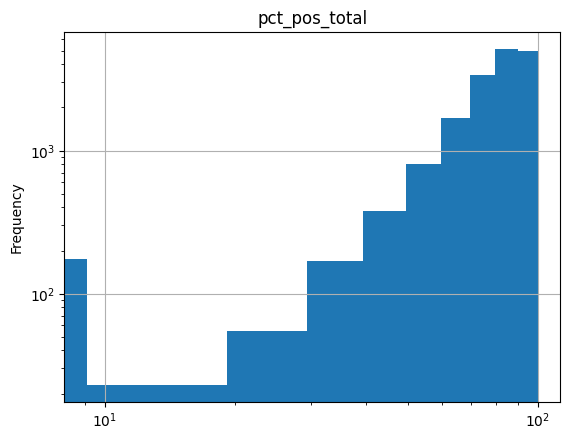

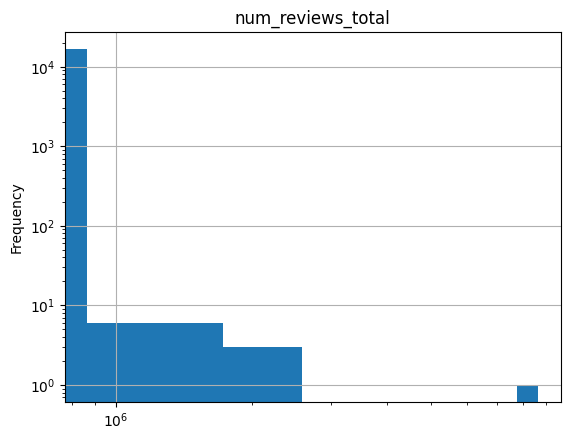

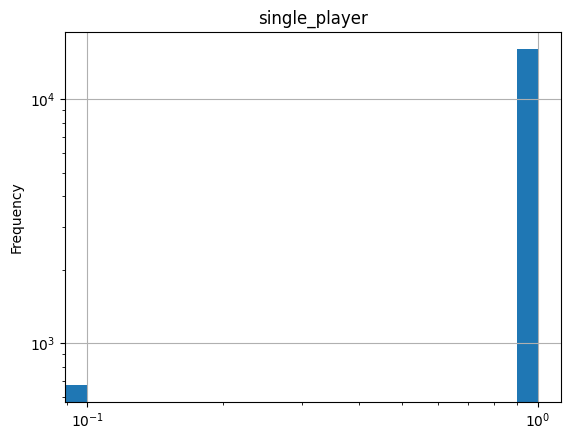

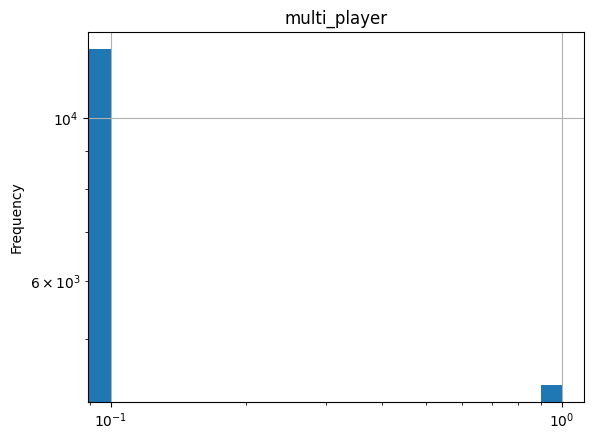

In [3]:
# Distribution des données
# For the columns with numbers, we can plot the histograms
# features=['release_year', 'required_age', 'price', 'metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']
# extract column names (numeric only to plot histograms)  
features = df.select_dtypes(include='number').columns.tolist()
print("Features:", features)

#histogrammes
for x in features:
  plt.figure()
  df[x].plot.hist(loglog=True)
  plt.title(x)
  plt.grid()
#même en affichant les données sous l'échelle logarithmique, on observe déjà des pics au niveau de 0 pour les données manquantes(le dataset n'est pas complet)

# #covariance & correlation
# df2=df[['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']]
# df2.corr() 
# #on observe qu'il y a qlq redondances dans notre jeux de données, les catégories recommendations, positive et num_reviews_total ont une correlation au dessus de 0.9.

# df.plot.scatter(x='peak_ccu',y='metacritic_score')
# df.plot.scatter(x='metacritic_score',y='recommendations')
# df.plot.scatter(x='positive',y='median_playtime_forever')
# #en testant qlq combinaisons de catégories en x et y (en évitant de prendre des catégories trop redondantes), 
# # on observe que les données ne se regroupe pas bien, se répartissant plus selon l'absence de données que formant des clusters cohérents

# df.sort_values("negative", ascending=False).head(1)


In [4]:
#we search for how much features are missing

missing = df.eq(0).sum()
lenght= len(df)
print(missing)
print("lenght total du data set =",lenght)

#on observe que beaucoup de données sont manquante sur ce dataset, en particulier sur les petits jeux qui représentent la majorité des sorties steam.

name                           0
release_year                   0
required_age               16038
price                        569
dlc_count                   9978
metacritic_score           13631
achievements                3719
recommendations                0
median_playtime_forever    10670
peak_ccu                    4953
pct_pos_total                  0
num_reviews_total              0
single_player                674
multi_player               12405
dtype: int64
lenght total du data set = 16737


In [5]:
# Supprimer l'outlier pour tester
# df = df[df['name'] != 'Counter-Strike 2']

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

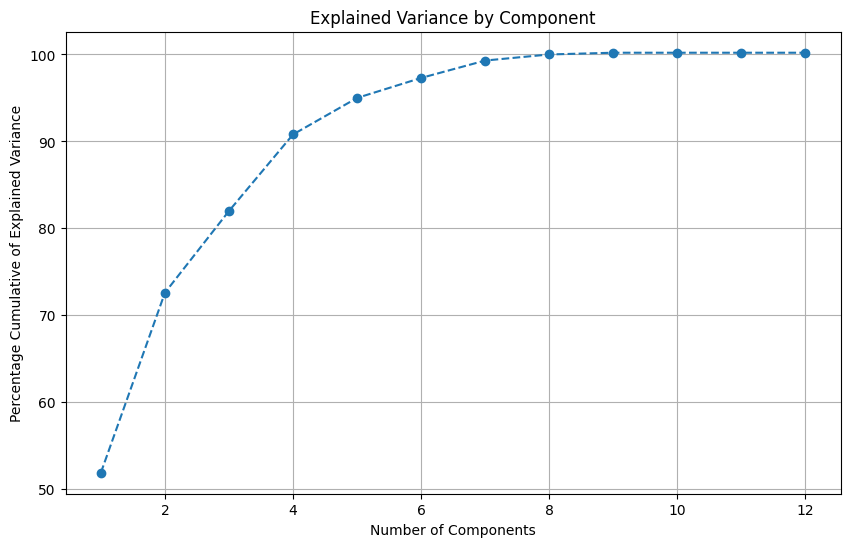

In [7]:
from sklearn.preprocessing import Normalizer

data = df.drop(columns=['name', 'release_year'])

df_normalized = Normalizer().fit_transform(data.values)
# print(df_normalized.shape)
# print(df_normalized)
pca = PCA()
pca.fit(df_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

In [8]:
pca = PCA(n_components = 6)
pca.fit(df_normalized)

data_pca = pca.transform(df_normalized)
df_reduced = pd.DataFrame(data_pca, columns = ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6'])
df_reduced.insert(0, "name", df['name'])
df_reduced.head(10)

# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(df_reduced["PCA1"], df_reduced["PCA2"], df_reduced["PCA3"], s=20, alpha=0.7)
# sc = ax.collections[-1]
# sc.set_array(df_reduced["PCA3"].values)
# sc.set_cmap("viridis")
# plt.colorbar(sc, ax=ax, label="PCA3 (color by Z)")
# ax.set_xlabel("PCA1")
# ax.set_ylabel("PCA2")
# ax.set_zlabel("PCA3")
# ax.set_title("3D Scatter Plot of PCA-Reduced Data")
# plt.show()

,name,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6
0,Counter-Strike 2,-0.078834,-0.164011,-0.298461,0.035700,0.108904,-0.025301
1,PUBG: BATTLEGROUNDS,-0.087033,-0.168776,-0.167494,0.052408,0.140247,-0.049701
2,Dota 2,0.039545,-0.096633,-0.690787,0.116415,0.299157,-0.013176
3,Grand Theft Auto V Legacy,-0.100773,-0.172729,0.006819,0.036311,0.028024,-0.009064
4,Tom Clancy's Rainbow Six® Siege,-0.101650,-0.172663,0.006283,0.037934,0.033566,-0.011379
5,Team Fortress 2,0.019347,-0.104538,-0.687260,0.076048,0.174820,0.032959
6,Terraria,-0.103843,-0.172208,0.004675,0.032992,0.012608,-0.001029
7,Rust,-0.095782,-0.171804,0.008274,0.053507,0.089337,-0.035972
8,Garry's Mod,-0.103029,-0.172313,0.006285,0.033407,0.014580,-0.002216
9,Apex Legends™,0.036046,-0.097481,-0.704074,0.102613,0.255467,0.006055


In [9]:
feature_names = data.columns

# Matrice des loadings (composantes)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

print(loadings)

                              PC1       PC2       PC3       PC4       PC5  \
required_age            -0.000178  0.000361  0.000223 -0.000436 -0.000695   
price                   -0.010877  0.100664  0.064517 -0.013000  0.051959   
dlc_count                0.000569  0.004566  0.005710  0.009174  0.014551   
metacritic_score        -0.002817  0.039529  0.001639 -0.004608 -0.025503   
achievements             0.009625  0.337790 -0.089152  0.678057 -0.562458   
recommendations         -0.337294 -0.204347  0.755235 -0.234492 -0.367168   
median_playtime_forever  0.867541 -0.089728  0.035547 -0.311498 -0.277403   
peak_ccu                 0.007935 -0.020275  0.025871  0.137089  0.594720   
pct_pos_total           -0.087853  0.876158  0.033046 -0.452740  0.020239   
num_reviews_total       -0.354405 -0.237060 -0.643777 -0.405159 -0.337954   
single_player           -0.001041  0.010446  0.000634 -0.005123 -0.000523   
multi_player            -0.000173  0.001683 -0.000043 -0.000750 -0.000166   

[[-0.07883403 -0.16401114 -0.2984607   0.03570018  0.10890436 -0.02530064]
 [-0.08703346 -0.16877556 -0.16749377  0.0524082   0.14024675 -0.04970059]
 [ 0.03954524 -0.09663304 -0.69078739  0.11641478  0.29915737 -0.01317634]
 ...
 [ 0.07742359 -0.03450362  0.64801076  0.3122854   0.36109941 -0.00505271]
 [ 0.05897013 -0.06870405  0.67892177  0.28547237  0.25488886  0.01159151]
 [ 0.17901021  0.09182654  0.43472317  0.35678987  0.40816101  0.11359445]]


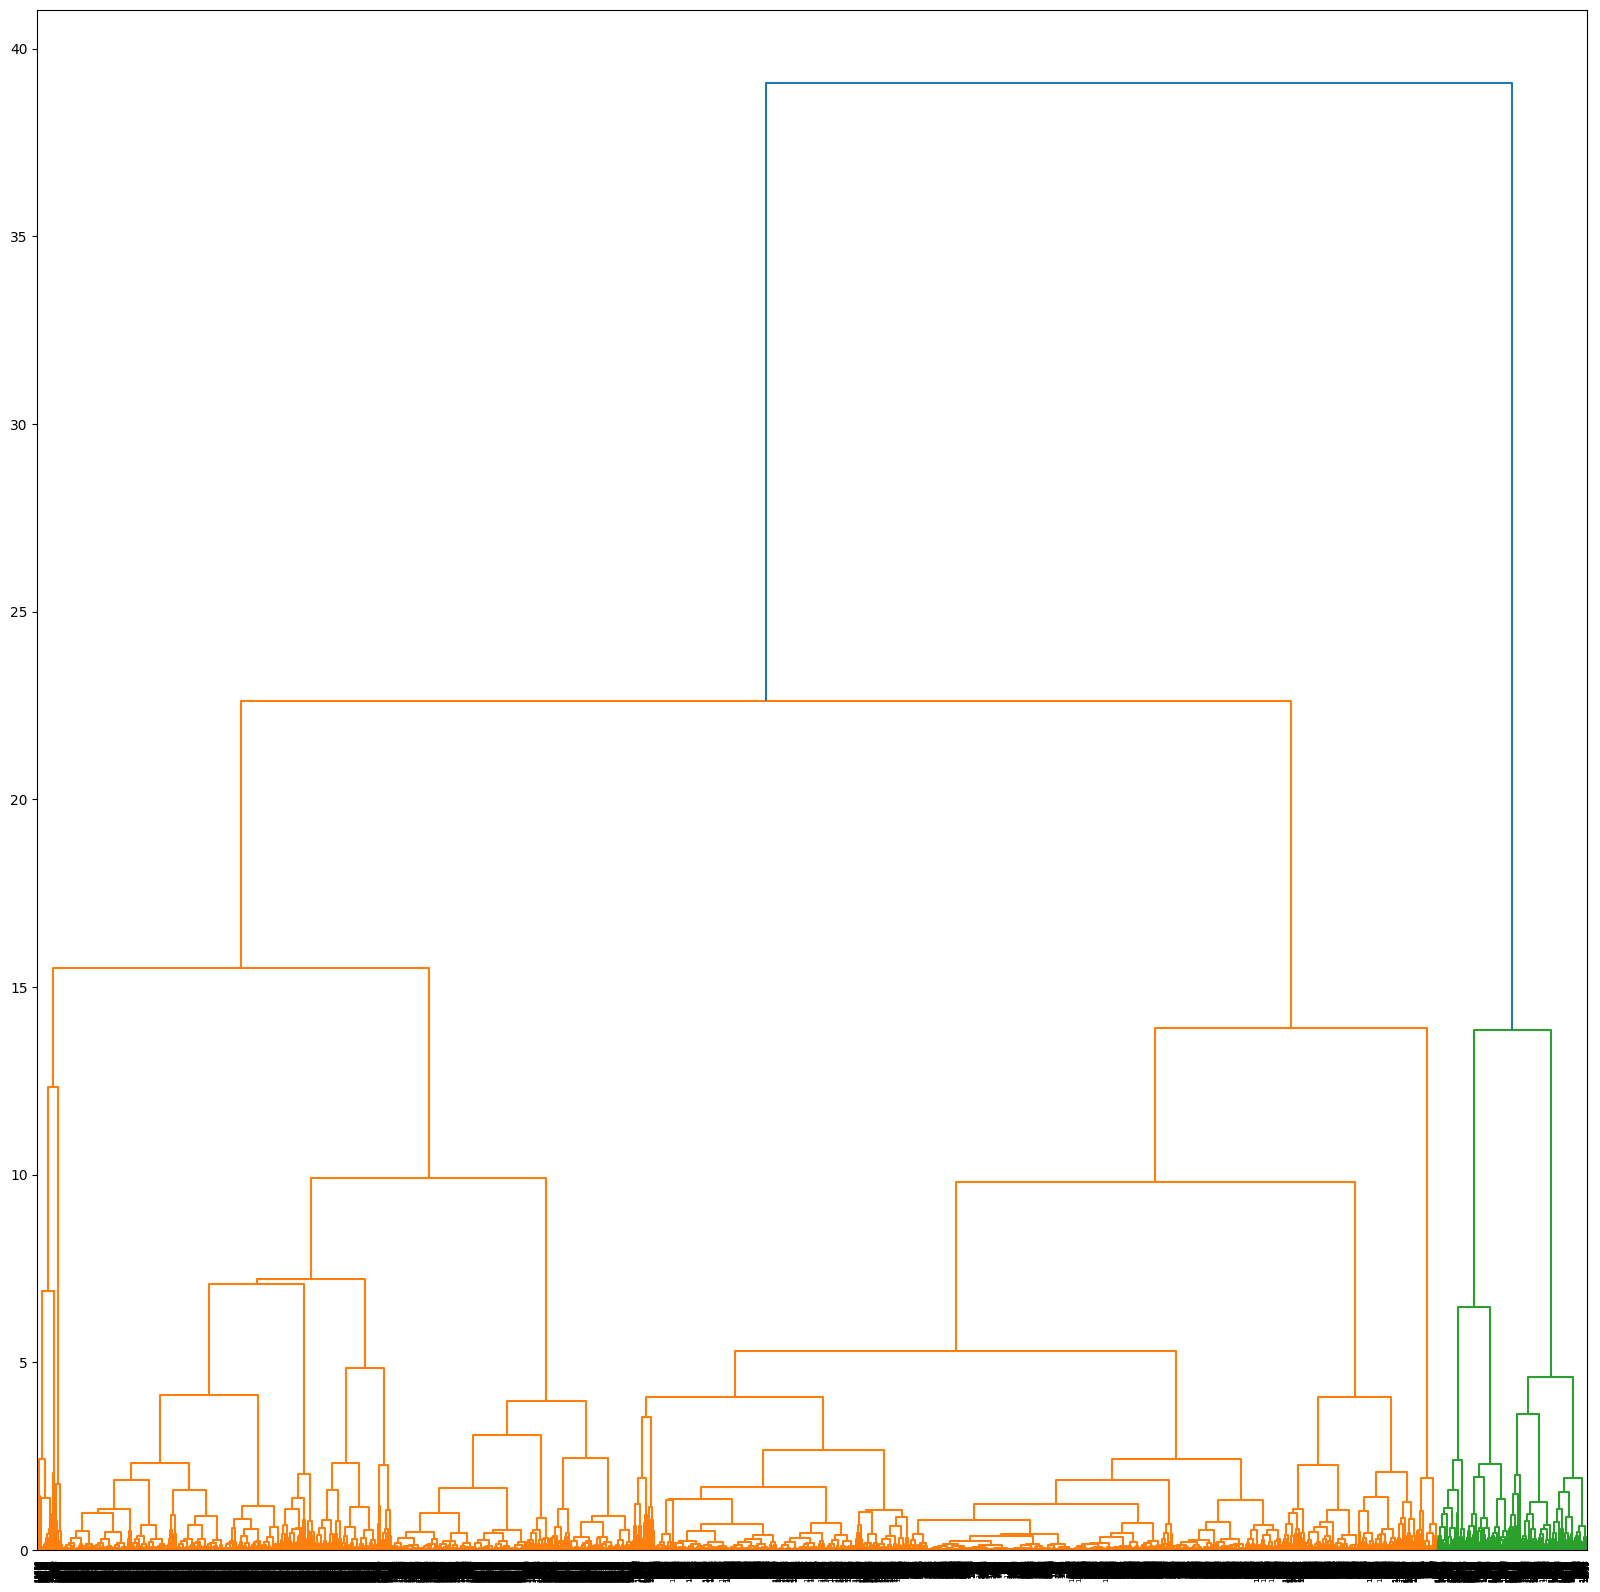

In [10]:
import scipy.cluster.hierarchy as shc

print(data_pca)

linked_mat = shc.linkage(data_pca, "ward")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()

In [11]:
import time
from sklearn import cluster
# set distance_threshold(0 ensures we compute the full tree)
# tps1 = time.time()
# model = cluster.AgglomerativeClustering(distance_threshold = 5 , \
#     linkage = "ward" , n_clusters = None)
# model = model.fit(data_pca)
# tps2 = time.time()

# labels = model.labels_
# nb_clusters = model.n_clusters_
# leaves = model.n_leaves_
# print("nb clusters =", nb_clusters ,", nb feuilles =", leaves , "runtime =", round (( tps2 - tps1) * 1000 , 2) ," ms")

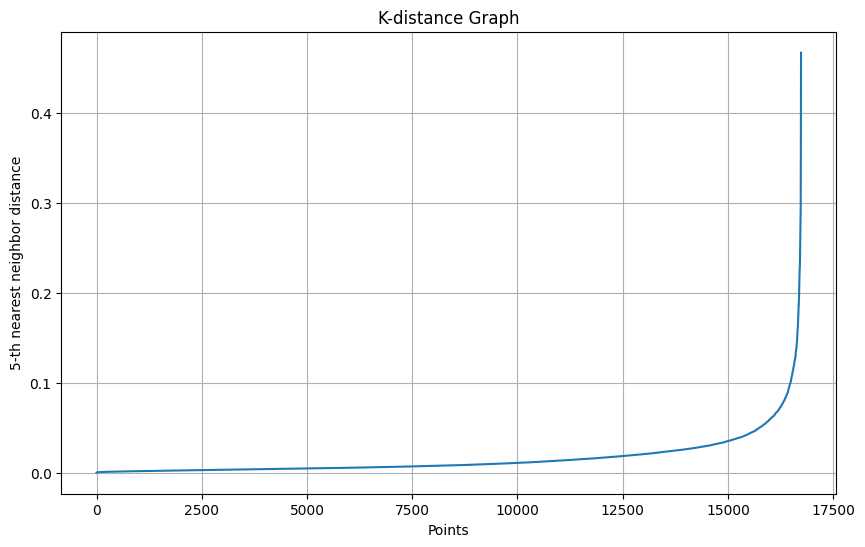

In [12]:
from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.grid()
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(data_pca, k=5)

In [20]:
# Essaie avec DBSCAN
from sklearn.cluster import DBSCAN
tps1 = time.time()
dbscan_model = DBSCAN(eps=0.05, min_samples=30)
dbscan_model.fit(data_pca)
tps2 = time.time()

labels = dbscan_model.labels_

df_clustered = df.copy()
df_clustered['Cluster'] = labels

cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print(cluster_counts)
nb_clusters = cluster_counts.shape[0]
df_clustered.head(100)

Cluster
-1     1784
 0    14290
 1      150
 2      334
 3       32
 4       43
 5      104
Name: count, dtype: int64


,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player,Cluster
0,Counter-Strike 2,2012,0,0.00,1,0,1,4401572,5174,1212356,86,8632939,0,1,-1
1,PUBG: BATTLEGROUNDS,2017,0,0.00,0,0,37,1732007,0,616738,59,2513842,0,1,-1
2,Dota 2,2013,0,0.00,2,90,0,14337,898,555977,81,2452595,0,1,-1
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,7101,117698,87,1803832,1,1,0
4,Tom Clancy's Rainbow Six® Siege,2015,17,3.99,9,0,0,1165929,2434,89916,84,1168020,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Divinity: Original Sin 2 - Definitive Edition,2017,0,44.99,3,93,97,163956,0,7461,95,164364,1,1,0
100,The Sims™ 4,2020,0,0.00,93,0,0,80026,205,49608,87,164317,1,0,-1
101,Human Fall Flat,2016,0,19.99,1,70,135,162205,0,2612,94,162416,1,1,0
102,Cuphead,2017,0,19.99,3,88,42,160213,426,1870,96,160447,1,1,0


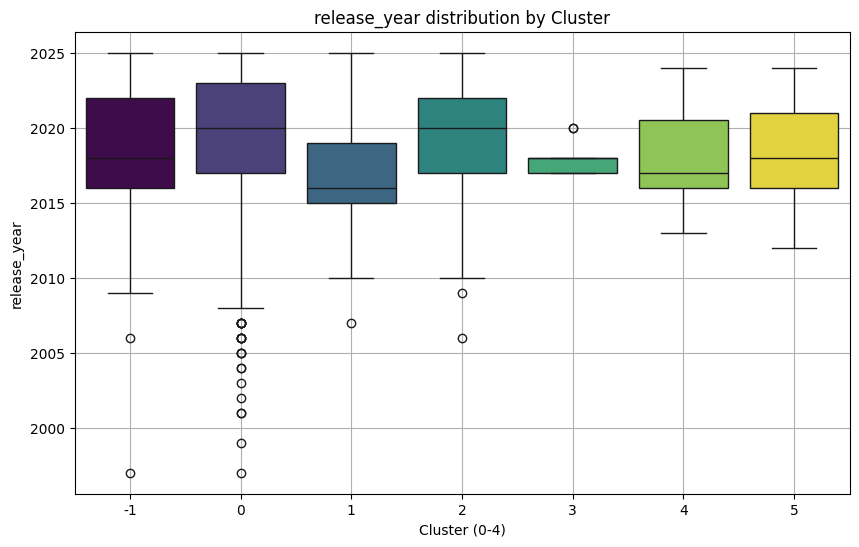

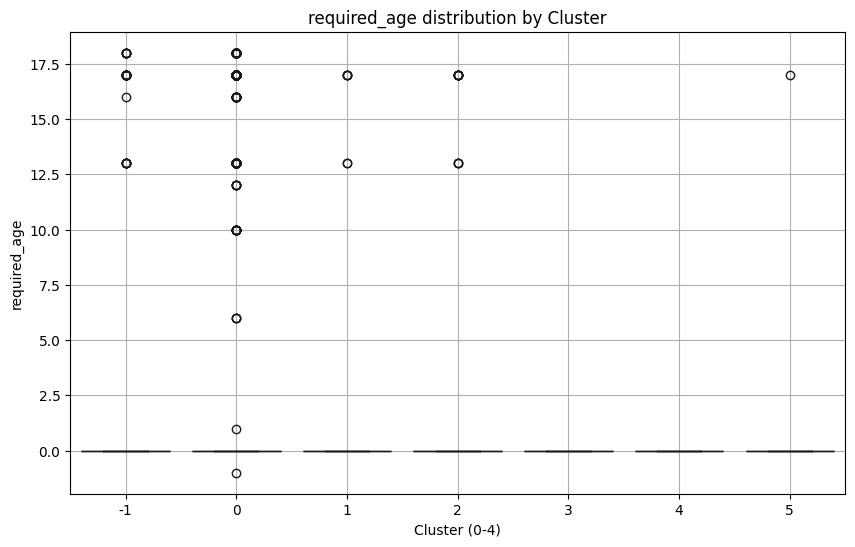

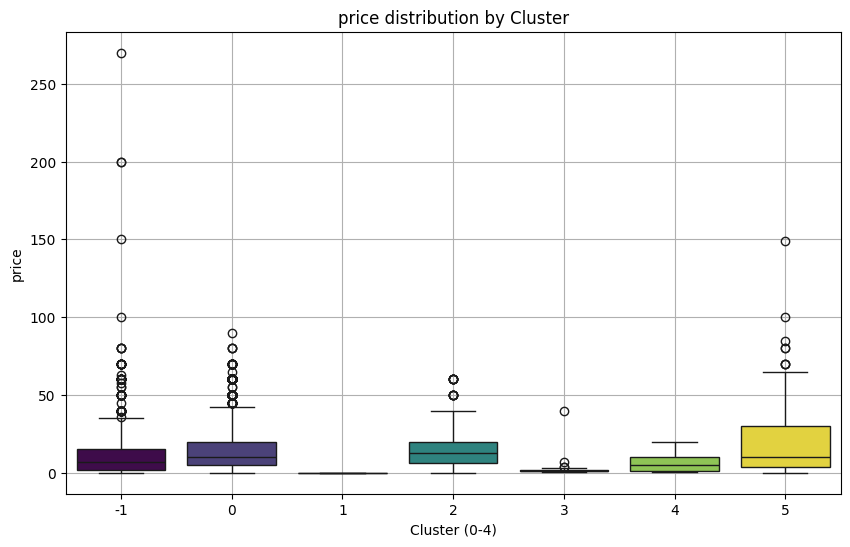

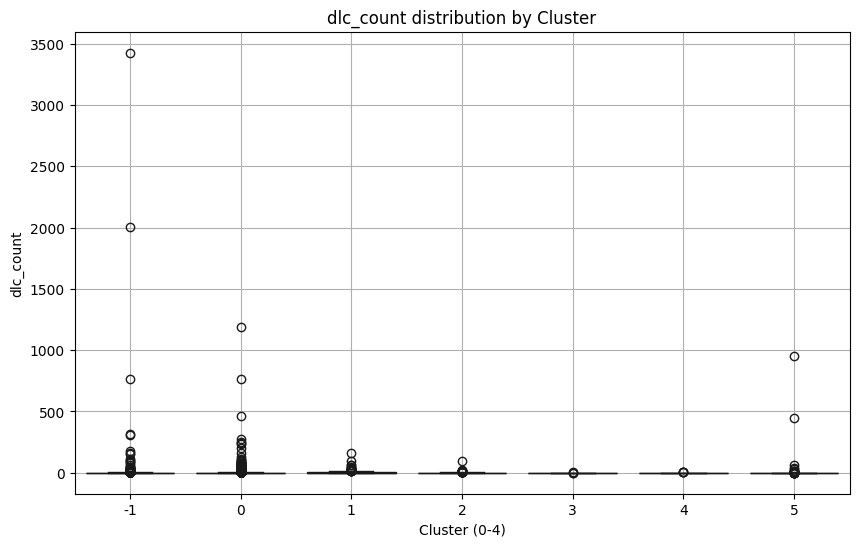

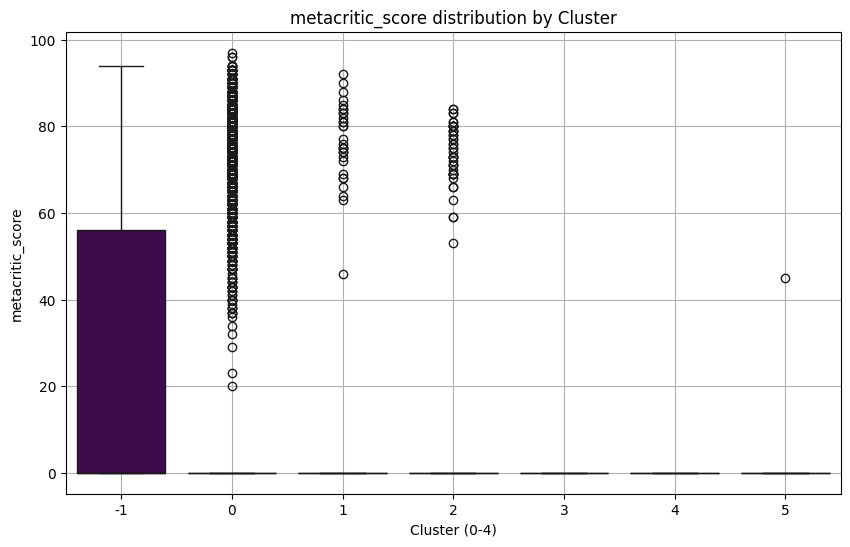

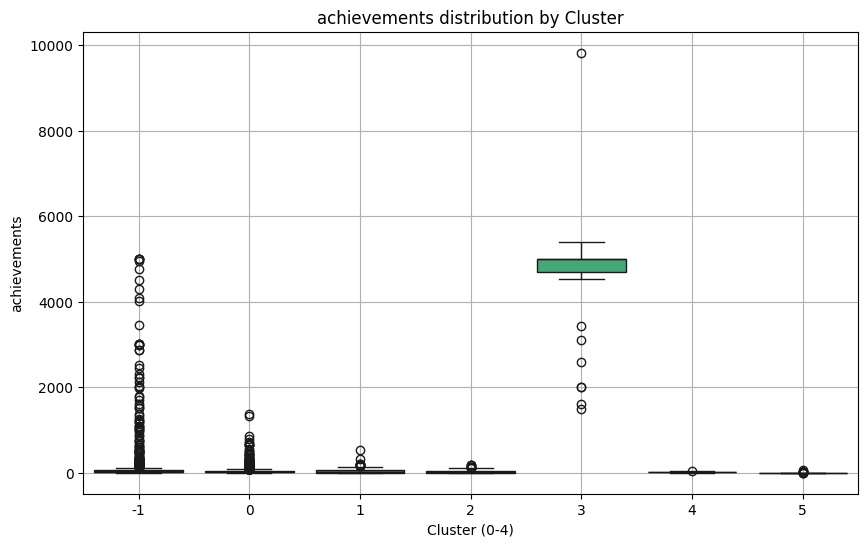

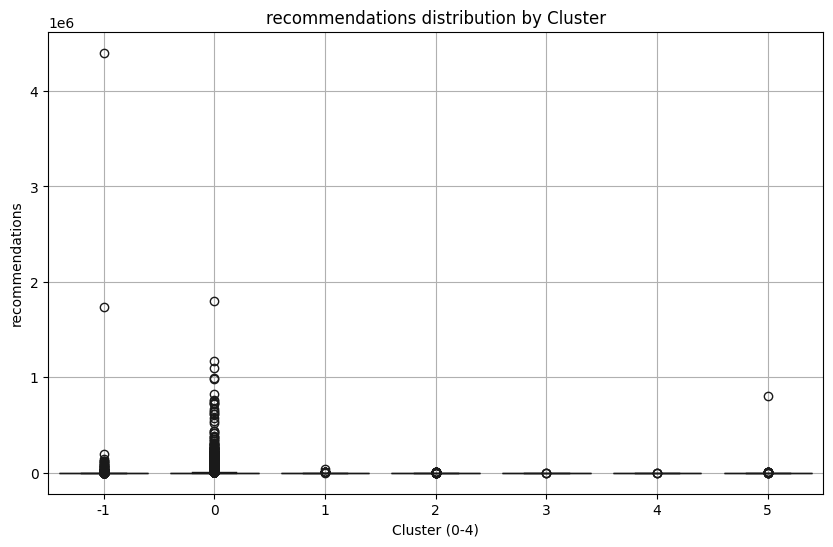

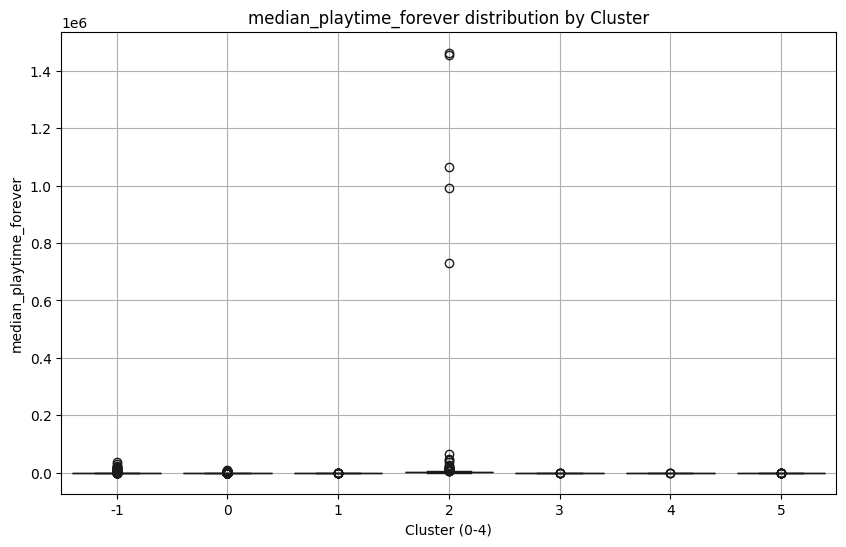

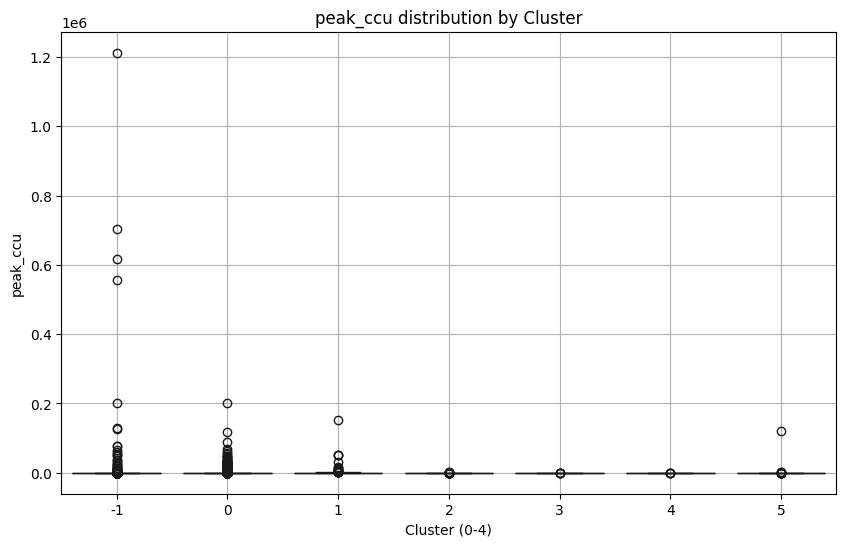

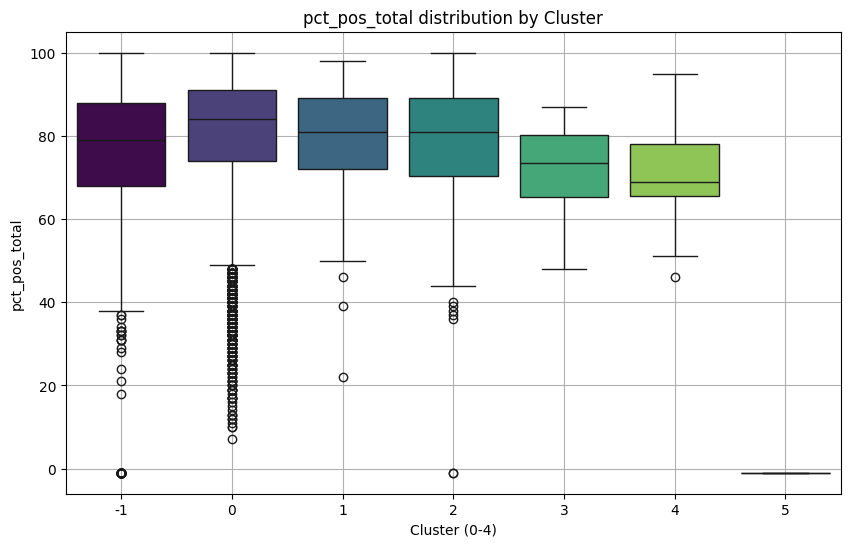

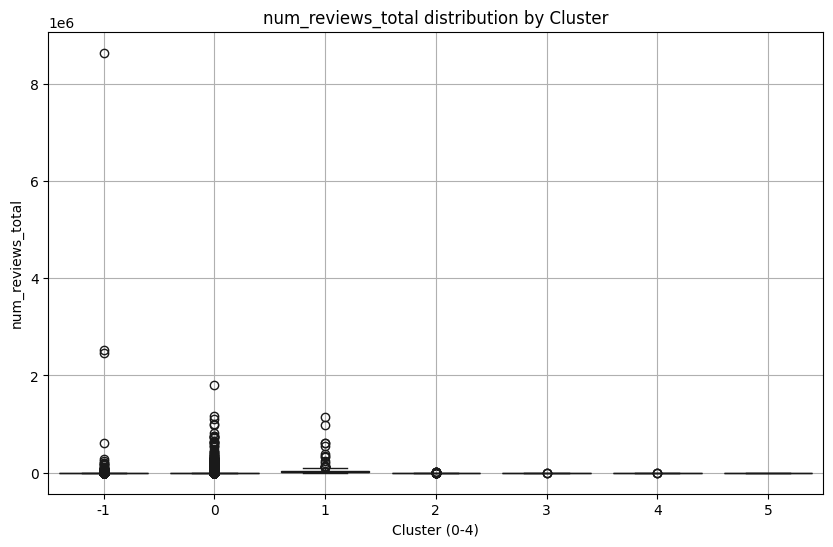

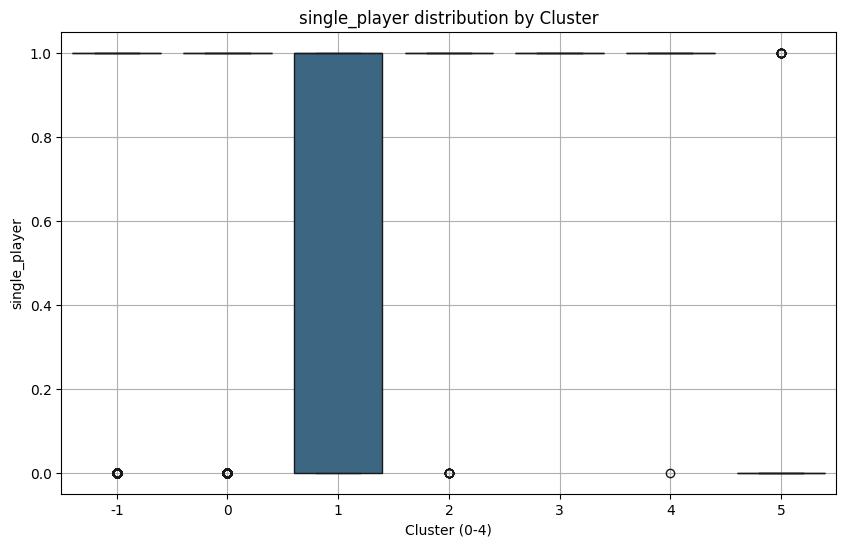

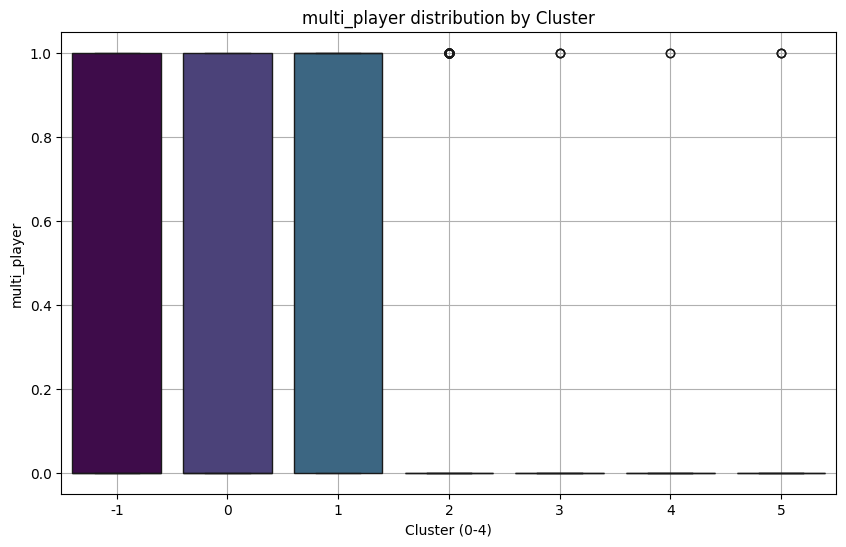

In [21]:
import seaborn as sns

for feature in features:
    # --- 2. Create the Plot ---
    plt.figure(figsize=(10, 6))

    # The Box Plot Command
    sns.boxplot(x='Cluster', y=feature, data=df_clustered, hue='Cluster', palette='viridis', legend=False)

    # Labeling
    plt.title(f'{feature} distribution by Cluster')
    plt.xlabel('Cluster (0-4)')
    plt.ylabel(feature)
    plt.grid()
    plt.show()

In [17]:
## Afficher les 10 jeux les plus recommandés par cluster
top_games = df_clustered[df_clustered['Cluster'] == -1].sort_values(by='recommendations', ascending=False).head(10)
print(f"Top 10 recommended games in Noise Cluster:")
print(top_games[['name', 'recommendations', 'pct_pos_total', 'price']])
print("\n")
for cluster_num in range(nb_clusters):
    top_games = df_clustered[df_clustered['Cluster'] == cluster_num].sort_values(by='recommendations', ascending=False).head(10)
    print(f"Top 10 recommended games in Cluster {cluster_num}:")
    print(top_games[['name', 'recommendations', 'pct_pos_total', 'price']])
    print("\n")

Top 10 recommended games in Noise Cluster:
                               name  recommendations  pct_pos_total  price
0                  Counter-Strike 2          4401572             86   0.00
1               PUBG: BATTLEGROUNDS          1732007             59   0.00
50               NARAKA: BLADEPOINT           194325             75   0.00
211                       Starbound           120017             90  14.99
182            Monster Hunter Wilds            88048             62  69.99
316                This War of Mine            84375             94  19.99
100                     The Sims™ 4            80026             87   0.00
56724                      Soundpad            75090             -1   4.99
82                         Lost Ark            65064             71   0.00
335    Kingdom Come: Deliverance II            56822             93  59.99


Top 10 recommended games in Cluster 0:
                               name  recommendations  pct_pos_total  price
3         Grand 